In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("monthly_milk_production.csv")
df

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727
...,...,...
163,1975-08,858
164,1975-09,817
165,1975-10,827
166,1975-11,797


In [3]:
df.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [4]:
df.shape

(168, 2)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        168 non-null    object
 1   Production  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB


In [7]:
#Convert Date Column
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)

In [8]:
df.isnull().sum()

Production    0
dtype: int64

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

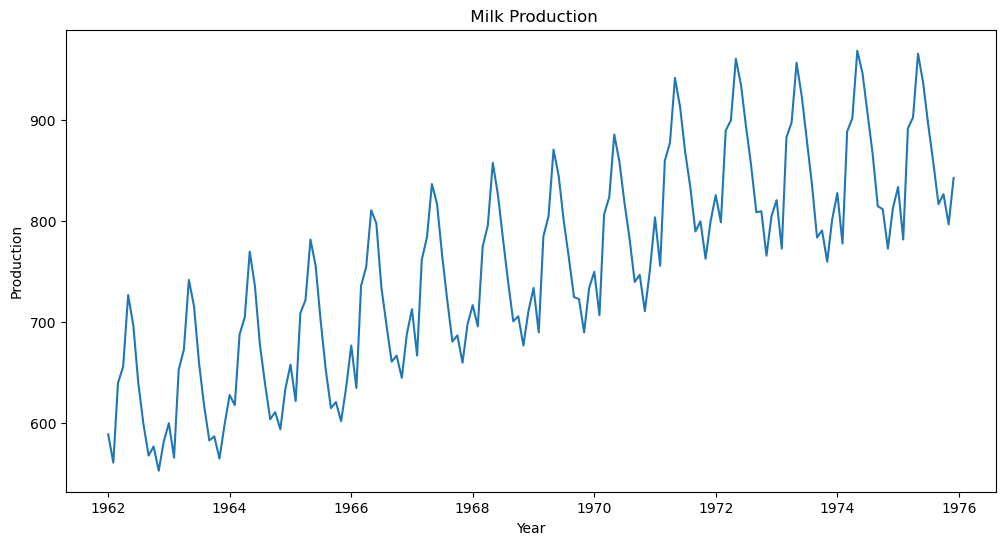

In [11]:
#Plot Time Series (Trend)
plt.figure(figsize=(12,6))

plt.plot(df["Production"])

plt.title(" Milk Production")

plt.xlabel("Year")

plt.ylabel("Production")

plt.show()

In [12]:
df.describe()

,Production
count,168.000000
mean,754.708333
std,102.204524
min,553.000000
25%,677.750000
50%,761.000000
75%,824.500000
max,969.000000


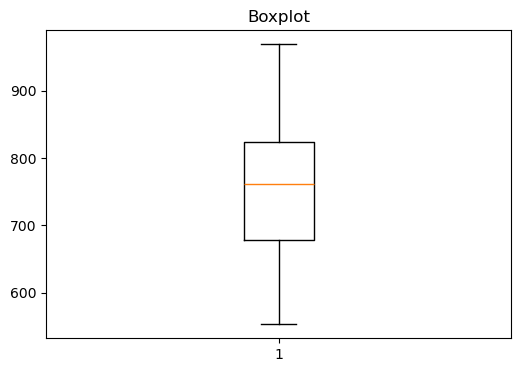

In [13]:
#Boxplot (Outliers)
plt.figure(figsize=(6,4))

plt.boxplot(df["Production"])

plt.title("Boxplot")

plt.show()

In [16]:
#Normalize Data
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df)

In [17]:
scaled_data[:10]

array([[0.08653846],
       [0.01923077],
       [0.20913462],
       [0.24759615],
       [0.41826923],
       [0.34615385],
       [0.20913462],
       [0.11057692],
       [0.03605769],
       [0.05769231]])

In [18]:
#Create Time Window Function
def create_dataset(dataset, time_step=12):
    X, y = [], []

    for i in range(len(dataset) - time_step):
        X.append(dataset[i:i + time_step, 0])
        y.append(dataset[i + time_step, 0])

    return np.array(X), np.array(y)

In [19]:
#Create Input and Output Sequences
time_step = 12

X, y = create_dataset(scaled_data, time_step)

In [20]:
#Check the Shape
print("X Shape :", X.shape)
print("y Shape :", y.shape)

X Shape : (156, 12)
y Shape : (156,)


In [21]:
#Split Data into Train and Test
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [22]:
#Check Train/Test Shapes
print("X_train :", X_train.shape)
print("X_test :", X_test.shape)

print("y_train :", y_train.shape)
print("y_test :", y_test.shape)

X_train : (124, 12)
X_test : (32, 12)
y_train : (124,)
y_test : (32,)


In [23]:
#Reshape Data for RNN/LSTM/GRU
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [24]:
#Verify the New Shape
print("X_train Shape :", X_train.shape)
print("X_test Shape :", X_test.shape)

X_train Shape : (124, 12, 1)
X_test Shape : (32, 12, 1)


In [28]:
#Build Basic RNN Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN,Dense


model_rnn = Sequential()

model_rnn.add(SimpleRNN(
    units=50,
    activation='tanh',
    input_shape=(X_train.shape[1], 1)
))

model_rnn.add(Dense(1))

In [29]:
#Compile the Model
model_rnn.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [30]:
#Display Model Summary
model_rnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)             │ (None, 50)                  │           2,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
#Train the RNN Model
history_rnn = model_rnn.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 139ms/step - loss: 0.1691 - val_loss: 0.0569
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0460 - val_loss: 0.0263
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0166 - val_loss: 0.0462
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0098 - val_loss: 0.0061
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0064 - val_loss: 0.0053
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0040 - val_loss: 0.0100
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0035 - val_loss: 0.0058
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0029 - val_loss: 0.0035
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0026 - val_loss: 0.0045
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0022 - val_loss: 0.0029
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0020 - val_loss: 0.0030
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0019 - val_loss: 0.0025


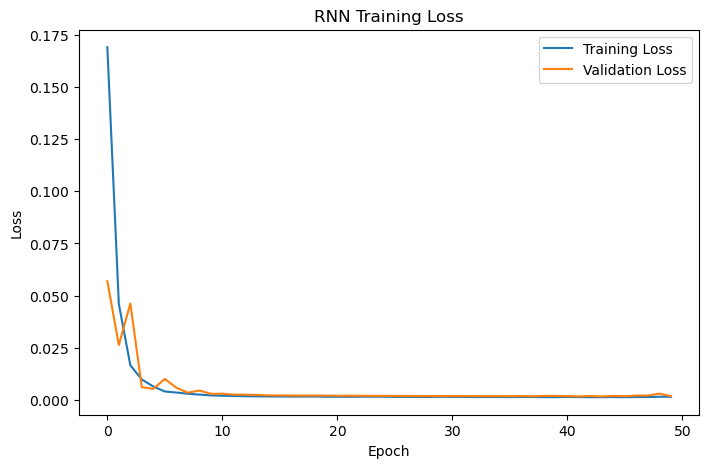

In [32]:
#Plot Training Loss
plt.figure(figsize=(8,5))

plt.plot(history_rnn.history['loss'], label='Training Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')

plt.title("RNN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [33]:
#Predict on Test Data
pred_rnn = model_rnn.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step


In [34]:
#Convert Predictions Back to Original Scale
pred_rnn = scaler.inverse_transform(pred_rnn)

actual = scaler.inverse_transform(y_test.reshape(-1,1))

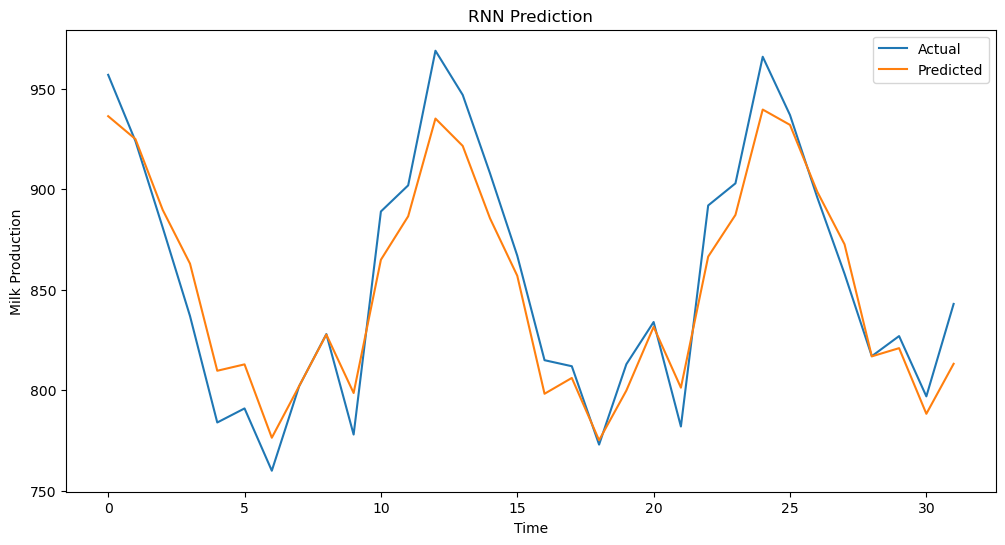

In [35]:
#Plot Actual vs Predicted
plt.figure(figsize=(12,6))

plt.plot(actual, label='Actual')
plt.plot(pred_rnn, label='Predicted')

plt.title("RNN Prediction")

plt.xlabel("Time")

plt.ylabel("Milk Production")

plt.legend()

plt.show()

In [36]:
#Calculate RMSE, MAE, and MAPE
from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse = np.sqrt(mean_squared_error(actual, pred_rnn))

mae = mean_absolute_error(actual, pred_rnn)

mape = np.mean(np.abs((actual - pred_rnn) / actual)) * 100

print("RNN RMSE :", rmse)
print("RNN MAE :", mae)
print("RNN MAPE :", mape)

RNN RMSE : 17.606011830954706
RNN MAE : 14.5750331878662
RNN MAPE : 1.6911178907499185


In [37]:
#Build LSTM Model
from tensorflow.keras.layers import LSTM
model_lstm = Sequential()

model_lstm.add(LSTM(
    units=50,
    activation='tanh',
    input_shape=(X_train.shape[1], 1)
))

model_lstm.add(Dense(1))

C:\Users\komal\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [38]:
#Compile LSTM Model
model_lstm.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [39]:
#Model Summary
model_lstm.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
#Train LSTM Model
history_lstm = model_lstm.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 150ms/step - loss: 0.1218 - val_loss: 0.0868
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0340 - val_loss: 0.0373
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0320 - val_loss: 0.0256
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0239 - val_loss: 0.0355
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0263 - val_loss: 0.0334
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0248 - val_loss: 0.0251
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0241 - val_loss: 0.0255
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - loss: 0.0234 - val_loss: 0.0268
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0232 - val_loss: 0.0257
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0228 - val_loss: 0.0244
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0231 - val_loss: 0.0243
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0224 - val_loss: 0.0253

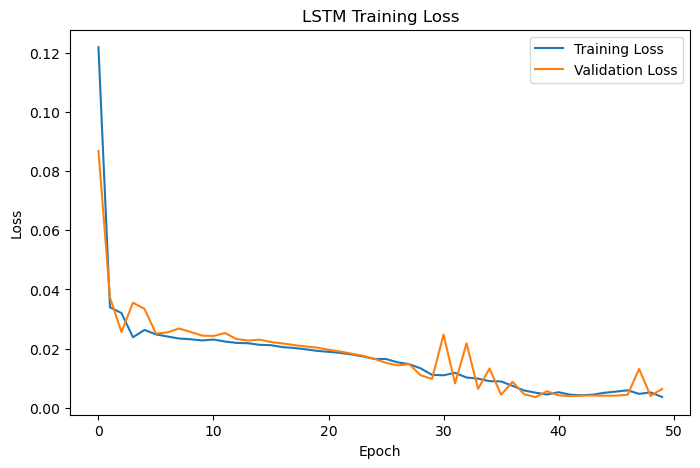

In [41]:
#Plot Training Loss
plt.figure(figsize=(8,5))

plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')

plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [42]:
#Predict Test Data
pred_lstm = model_lstm.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 567ms/step


In [43]:
#Convert Predictions Back to Original Scale
pred_lstm = scaler.inverse_transform(pred_lstm)

actual = scaler.inverse_transform(y_test.reshape(-1,1))

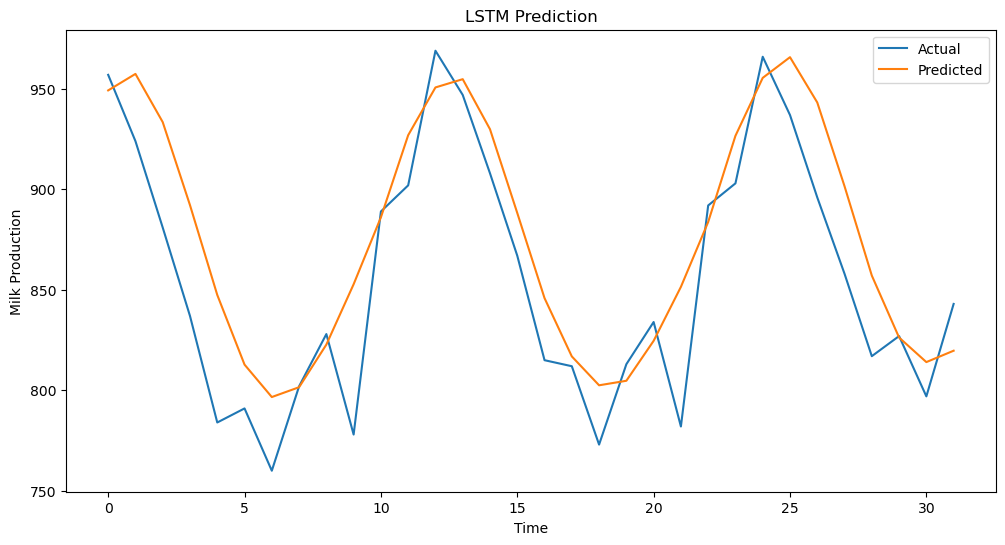

In [44]:
#Plot Actual vs Predicted
plt.figure(figsize=(12,6))

plt.plot(actual, label='Actual')

plt.plot(pred_lstm, label='Predicted')

plt.title("LSTM Prediction")

plt.xlabel("Time")

plt.ylabel("Milk Production")

plt.legend()

plt.show()

In [45]:
#Calculate RMSE, MAE, and MAPE
rmse_lstm = np.sqrt(mean_squared_error(actual, pred_lstm))

mae_lstm = mean_absolute_error(actual, pred_lstm)

mape_lstm = np.mean(np.abs((actual - pred_lstm) / actual)) * 100

print("LSTM RMSE :", rmse_lstm)

print("LSTM MAE :", mae_lstm)

print("LSTM MAPE :", mape_lstm)

LSTM RMSE : 33.24844671621825
LSTM MAE : 26.372638702392567
LSTM MAPE : 3.150272643221678


In [47]:
#Build GRU Model
from tensorflow.keras.layers import GRU
model_gru = Sequential()

model_gru.add(GRU(
    units=50,
    activation='tanh',
    input_shape=(X_train.shape[1], 1)
))

model_gru.add(Dense(1))

C:\Users\komal\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [48]:
#Compile GRU Model
model_gru.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [49]:
#Model Summary
model_gru.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 50)                  │           7,950 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,001 (31.25 KB)

 Trainable params: 8,001 (31.25 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
#Train GRU Model
history_gru = model_gru.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 171ms/step - loss: 0.2326 - val_loss: 0.3262
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0913 - val_loss: 0.0880
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0351 - val_loss: 0.0271
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0376 - val_loss: 0.0276
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0295 - val_loss: 0.0440
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0300 - val_loss: 0.0483
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0284 - val_loss: 0.0333
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0266 - val_loss: 0.0302
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0259 - val_loss: 0.0302
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0252 - val_loss: 0.0300
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0245 - val_loss: 0.0302
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0239 - val_loss: 0.0282


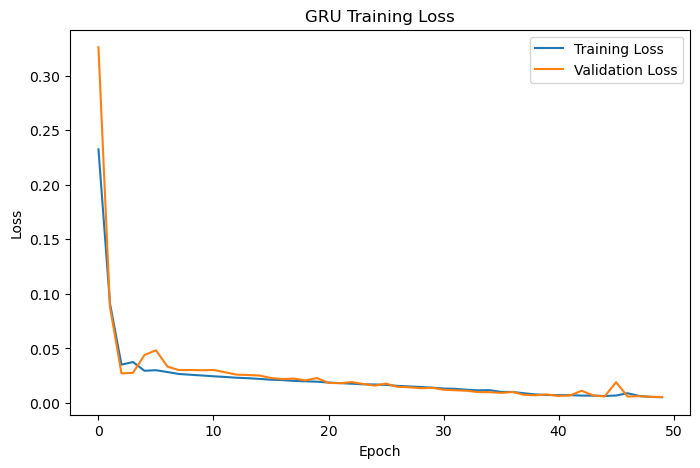

In [51]:
#Plot Training Loss
plt.figure(figsize=(8,5))

plt.plot(history_gru.history['loss'], label='Training Loss')
plt.plot(history_gru.history['val_loss'], label='Validation Loss')

plt.title("GRU Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [52]:
#Predict Test Data
pred_gru = model_gru.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 583ms/step


In [53]:
#Convert Predictions Back to Original Scale
pred_gru = scaler.inverse_transform(pred_gru)

actual = scaler.inverse_transform(y_test.reshape(-1,1))

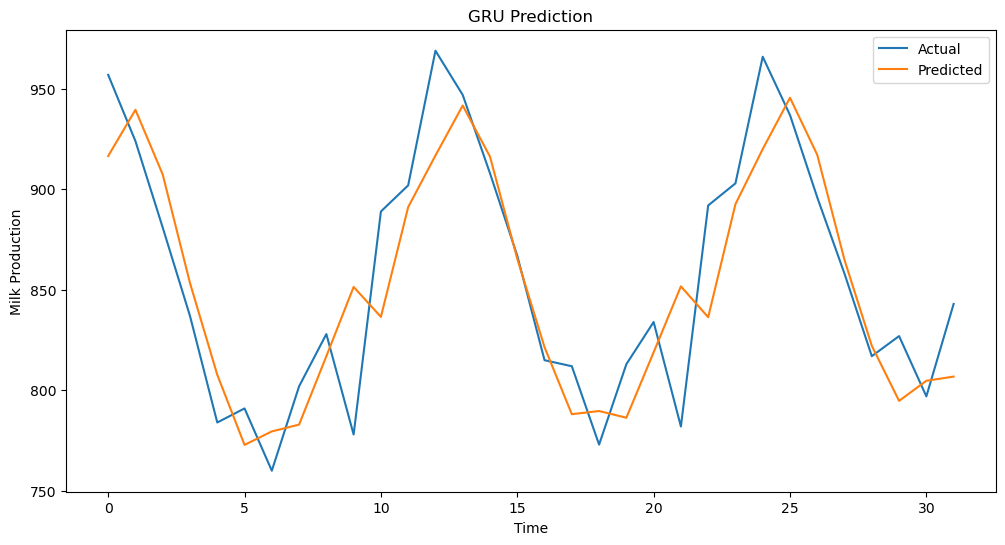

In [54]:
#Plot Actual vs Predicted
plt.figure(figsize=(12,6))

plt.plot(actual, label='Actual')

plt.plot(pred_gru, label='Predicted')

plt.title("GRU Prediction")

plt.xlabel("Time")

plt.ylabel("Milk Production")

plt.legend()

plt.show()

In [55]:
#Calculate RMSE, MAE, and MAPE
rmse_gru = np.sqrt(mean_squared_error(actual, pred_gru))

mae_gru = mean_absolute_error(actual, pred_gru)

mape_gru = np.mean(np.abs((actual - pred_gru) / actual)) * 100

print("GRU RMSE :", rmse_gru)
print("GRU MAE :", mae_gru)
print("GRU MAPE :", mape_gru)

GRU RMSE : 30.966830356544296
GRU MAE : 24.452911376953114
GRU MAPE : 2.872711149379956


In [56]:
#Compare RNN, LSTM, and GRU
results = pd.DataFrame({
    "Model": ["RNN", "LSTM", "GRU"],
    "RMSE": [rmse, rmse_lstm, rmse_gru],
    "MAE": [mae, mae_lstm, mae_gru],
    "MAPE": [mape, mape_lstm, mape_gru]
})

results

,Model,RMSE,MAE,MAPE
0,RNN,17.606012,14.575033,1.691118
1,LSTM,33.248447,26.372639,3.150273
2,GRU,30.966830,24.452911,2.872711


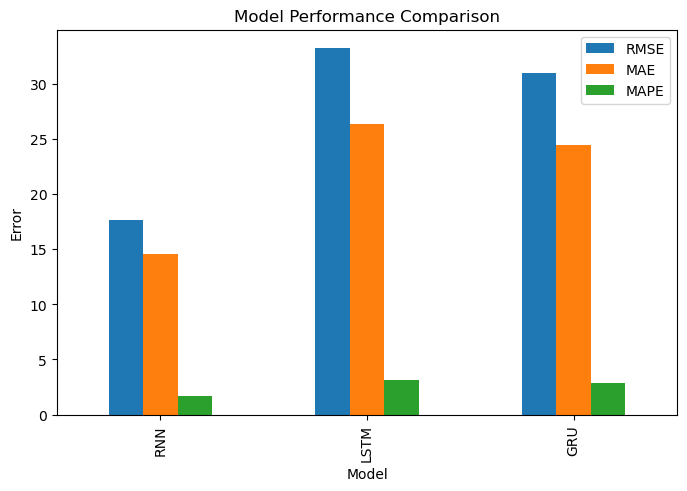

In [57]:
#Plot Model Comparison
results.set_index("Model").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Performance Comparison")

plt.ylabel("Error")

plt.show()

In [58]:
#Retrain the Best Model
model = model_rnn

In [59]:
#Prepare the Last 12 Months
last_sequence = scaled_data[-12:]

last_sequence = last_sequence.reshape(1, 12, 1)

In [60]:
#Forecast Next 12 Months
future_predictions = []

current_sequence = last_sequence.copy()

for i in range(12):

    next_value = model.predict(current_sequence, verbose=0)

    future_predictions.append(next_value[0][0])

    current_sequence = np.append(
        current_sequence[:,1:,:],
        [[[next_value[0][0]]]],
        axis=1
    )

In [61]:
#Convert Predictions to Original Scale
future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)

future_predictions

array([[841.92834],
       [804.7513 ],
       [871.6565 ],
       [882.92865],
       [932.5074 ],
       [919.5343 ],
       [892.9481 ],
       [867.1154 ],
       [826.1225 ],
       [834.07806],
       [807.9958 ],
       [836.7184 ]], dtype=float32)

In [62]:
#Create Future Dates
last_date = df.index[-1]

future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=12,
    freq='MS'
)

In [63]:
#Create Forecast DataFrame
forecast = pd.DataFrame(
    future_predictions,
    index=future_dates,
    columns=["Forecast"]
)

forecast

,Forecast
1976-01-01,841.928345
1976-02-01,804.751282
1976-03-01,871.656494
1976-04-01,882.928650
1976-05-01,932.507385
1976-06-01,919.534302
1976-07-01,892.948120
1976-08-01,867.115417
1976-09-01,826.122498
1976-10-01,834.078064


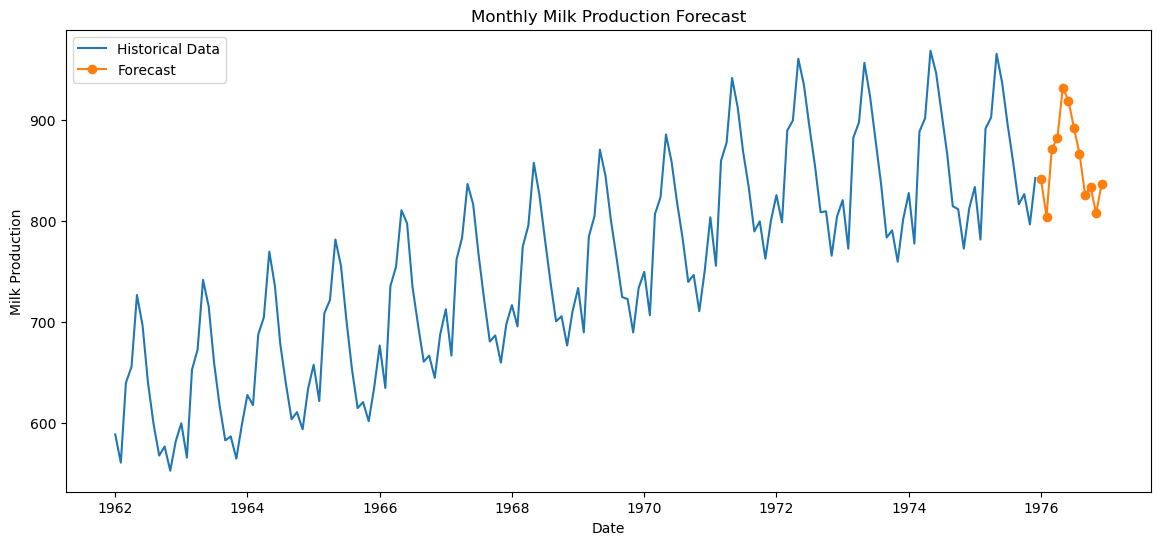

In [67]:
#Plot Forecast
plt.figure(figsize=(14,6))

plt.plot(df.index, df["Production"], label="Historical Data")

plt.plot(forecast.index,
         forecast["Forecast"],
         marker='o',
         label="Forecast")

plt.title("Monthly Milk Production Forecast")

plt.xlabel("Date")

plt.ylabel("Milk Production")

plt.legend()

plt.show()

In [68]:
#Display Forecast Values
forecast

,Forecast
1976-01-01,841.928345
1976-02-01,804.751282
1976-03-01,871.656494
1976-04-01,882.928650
1976-05-01,932.507385
1976-06-01,919.534302
1976-07-01,892.948120
1976-08-01,867.115417
1976-09-01,826.122498
1976-10-01,834.078064


In [69]:
#Final Model Comparison
comparison = pd.DataFrame({
    "Model": ["RNN", "LSTM", "GRU"],
    "RMSE": [rmse, rmse_lstm, rmse_gru],
    "MAE": [mae, mae_lstm, mae_gru],
    "MAPE": [mape, mape_lstm, mape_gru]
})

comparison.sort_values(by="RMSE")

,Model,RMSE,MAE,MAPE
0,RNN,17.606012,14.575033,1.691118
2,GRU,30.966830,24.452911,2.872711
1,LSTM,33.248447,26.372639,3.150273


Conclusion

• RNN, LSTM, and GRU models were developed for monthly milk production forecasting.

• The models were evaluated using RMSE, MAE, and MAPE.

• Among the three models, the RNN model achieved the lowest error values and showed the best forecasting performance.

• The RNN model was selected to forecast milk production for the next 12 months.

• The forecast can help the dairy industry improve production planning, inventory management, and resource allocation.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense

import math